In [2]:
import os
import sys
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data

In [3]:
df = load_data("data/creditcard.csv")
missing_values = df.isnull().sum()
print("\nNumber of missing values: ", missing_values[missing_values > 0])
# 1. Data overview
print(f"Shape: {df.shape}")
print(f"Duplicated rows: {df.duplicated().sum()}")
display(df.describe().T)

class_pct = df["Class"].value_counts(normalize=True).mul(100)
display(class_pct.rename("percentage (%)").to_frame())

Successfully loaded dataset

Number of missing values:  Series([], dtype: int64)
Shape: (284807, 31)
Duplicated rows: 1081


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


,percentage (%)
Class,
0,99.827251
1,0.172749


In [4]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64


C:\Users\QTD\AppData\Local\Temp\ipykernel_17236\3902392594.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


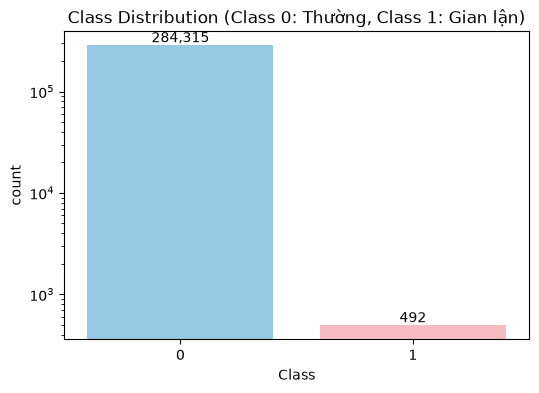

In [9]:
# Đếm số lượng giao dịch thường (0) và gian lận (1)
from matplotlib import legend


count_classes = df['Class'].value_counts()
print(count_classes)

# Trực quan hóa
plt.figure(figsize=(6, 4))
pastel_palette = ['#89cff0', '#ffb3ba'] # Xanh pastel (#89cff0) và Đỏ pastel (#ffb3ba)

sns.countplot(
    x='Class', 
    data=df, 
    palette=pastel_palette,
    legend=False,)
plt.title('Class Distribution (Class 0: Thường, Class 1: Gian lận)')
plt.yscale('log') # Dùng log scale vì Class 0 rất nhiều so với Class 1

for i, value in enumerate(count_classes.values):
    plt.text(i, value, f"{value:,}", ha="center", va="bottom")
plt.show()

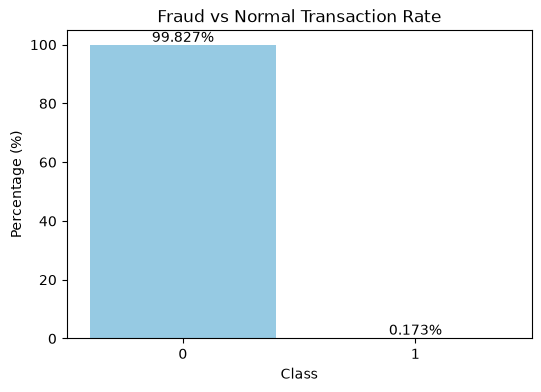

In [ ]:
# 2. Class proportions — easier to read than counts alone
plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=class_pct.index,
    y=class_pct.values,
    hue=class_pct.index,
    palette=["#89cff0", "#ffb3ba"],
    legend=False,
)

plt.title("Fraud vs Normal Transaction Rate")
plt.xlabel("Class")
plt.ylabel("Percentage (%)")

for i, value in enumerate(class_pct.values):
    ax.text(i, value, f"{value:.3f}%", ha="center", va="bottom")

plt.show()

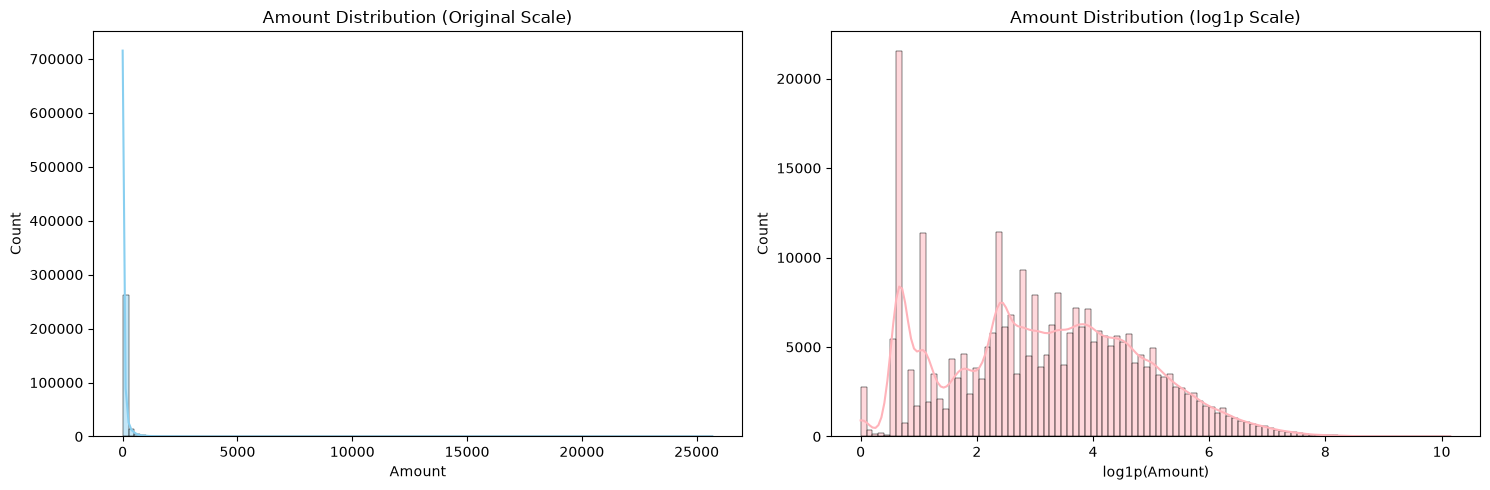

In [ ]:
# 3. Amount distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["Amount"], bins=100, kde=True, ax=axes[0], color="#89cff0")
axes[0].set_title("Amount Distribution (Original Scale)")
axes[0].set_xlabel("Amount")

sns.histplot(np.log1p(df["Amount"]), bins=100, kde=True, ax=axes[1], color="#ffb3ba")
axes[1].set_title("Amount Distribution (log1p Scale)")
axes[1].set_xlabel("log1p(Amount)")

plt.tight_layout()
plt.show()

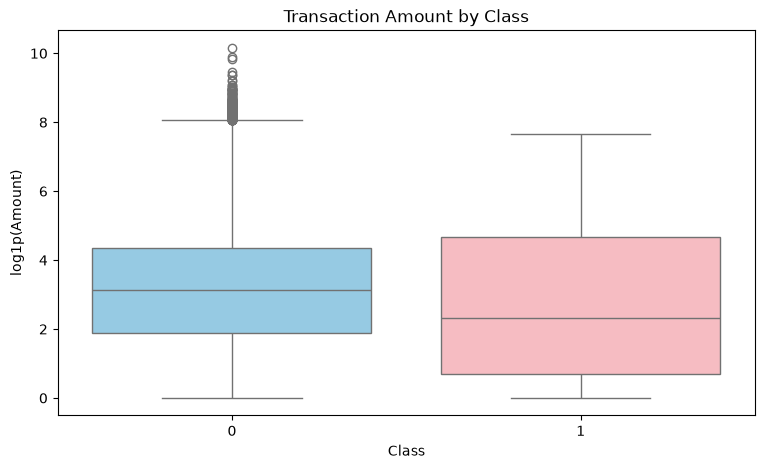

In [ ]:
# 4. Amount comparison by class
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Class",
    y=np.log1p(df["Amount"]),
    hue="Class",
    palette=["#89cff0", "#ffb3ba"],
    legend=False,
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("log1p(Amount)")
plt.show()

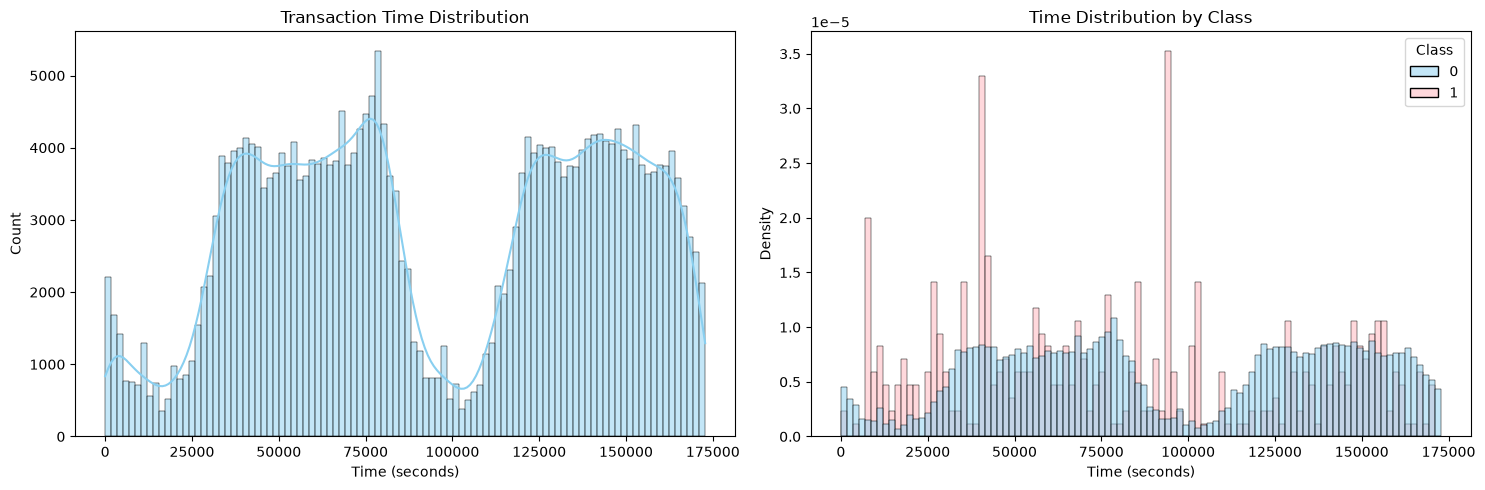

In [ ]:
# 5. Time distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["Time"], bins=100, kde=True, ax=axes[0], color="#89cff0")
axes[0].set_title("Transaction Time Distribution")
axes[0].set_xlabel("Time (seconds)")

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False,
    ax=axes[1],
    palette=["#89cff0", "#ffb3ba"],
)
axes[1].set_title("Time Distribution by Class")
axes[1].set_xlabel("Time (seconds)")

plt.tight_layout()
plt.show()

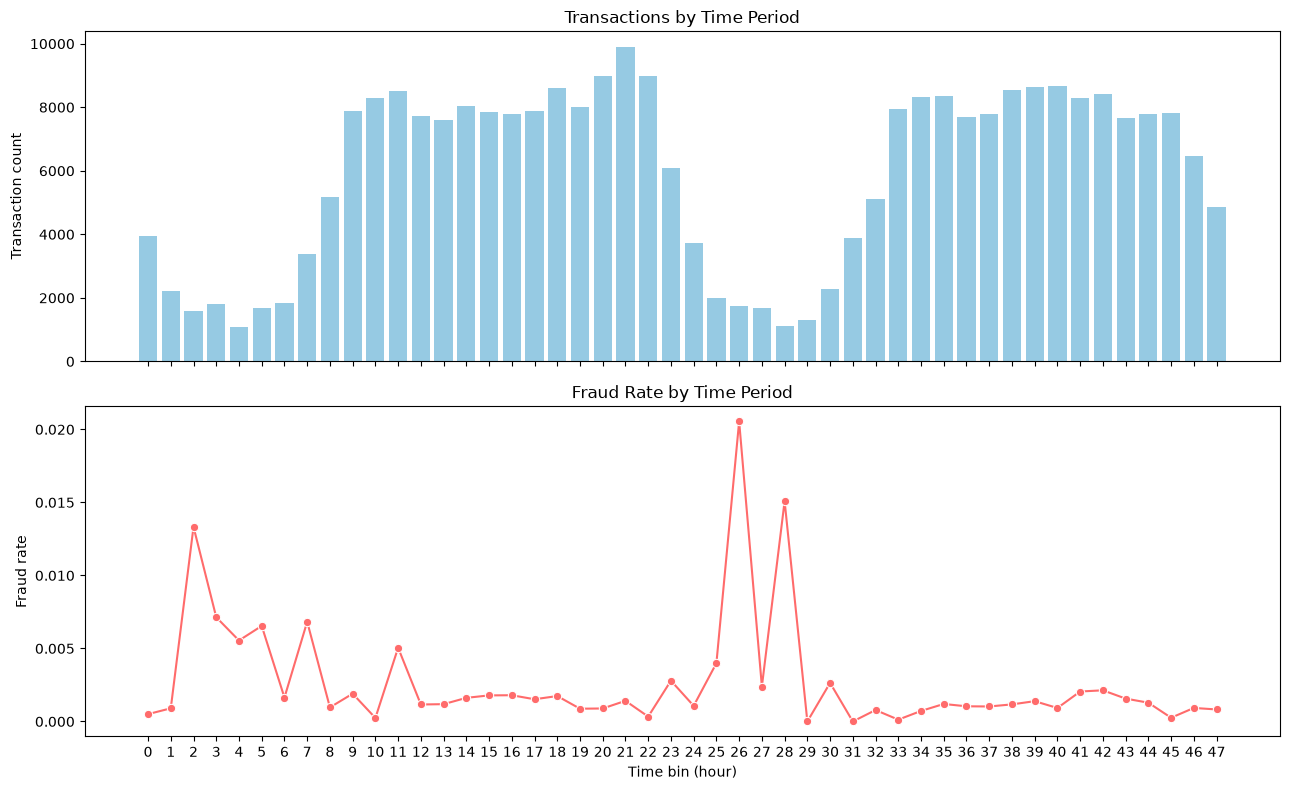

In [ ]:
# 6. Fraud rate across time periods (one-hour bins)
time_summary = (
    df.assign(time_hour=(df["Time"] // 3600).astype(int))
      .groupby("time_hour")
      .agg(
          transactions=("Class", "size"),
          fraud_rate=("Class", "mean"),
      )
      .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

sns.barplot(data=time_summary, x="time_hour", y="transactions", ax=axes[0], color="#89cff0")
axes[0].set_title("Transactions by Time Period")
axes[0].set_ylabel("Transaction count")

sns.lineplot(data=time_summary, x="time_hour", y="fraud_rate", marker="o", ax=axes[1], color="#ff6b6b")
axes[1].set_title("Fraud Rate by Time Period")
axes[1].set_xlabel("Time bin (hour)")
axes[1].set_ylabel("Fraud rate")

plt.tight_layout()
plt.show()

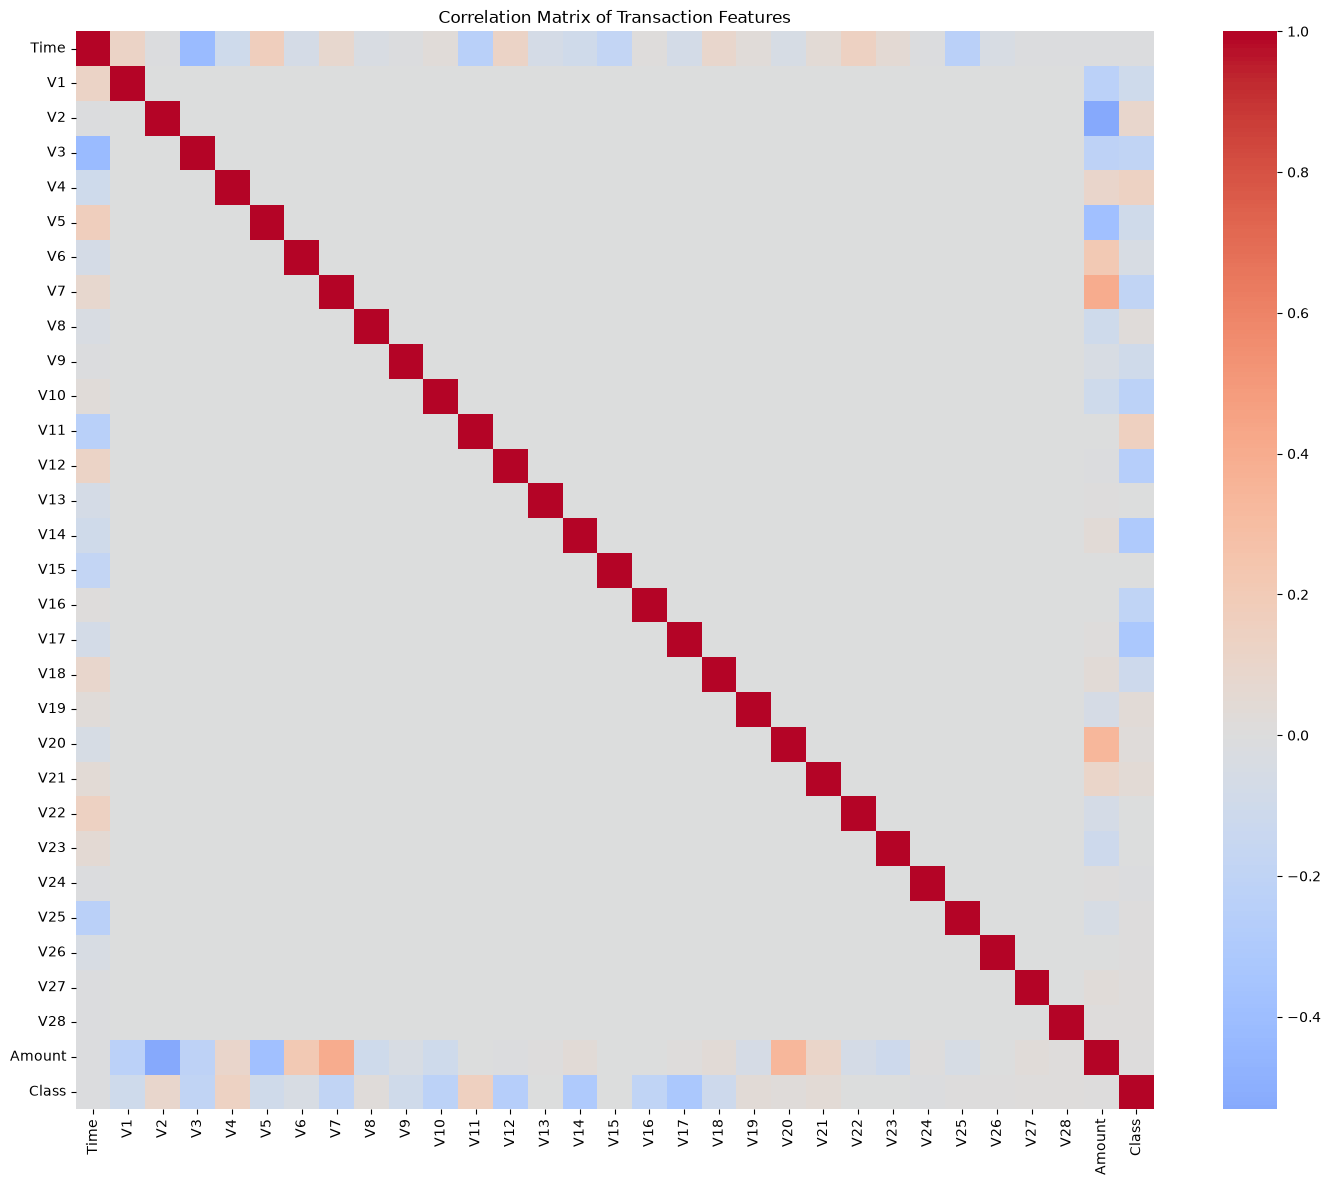

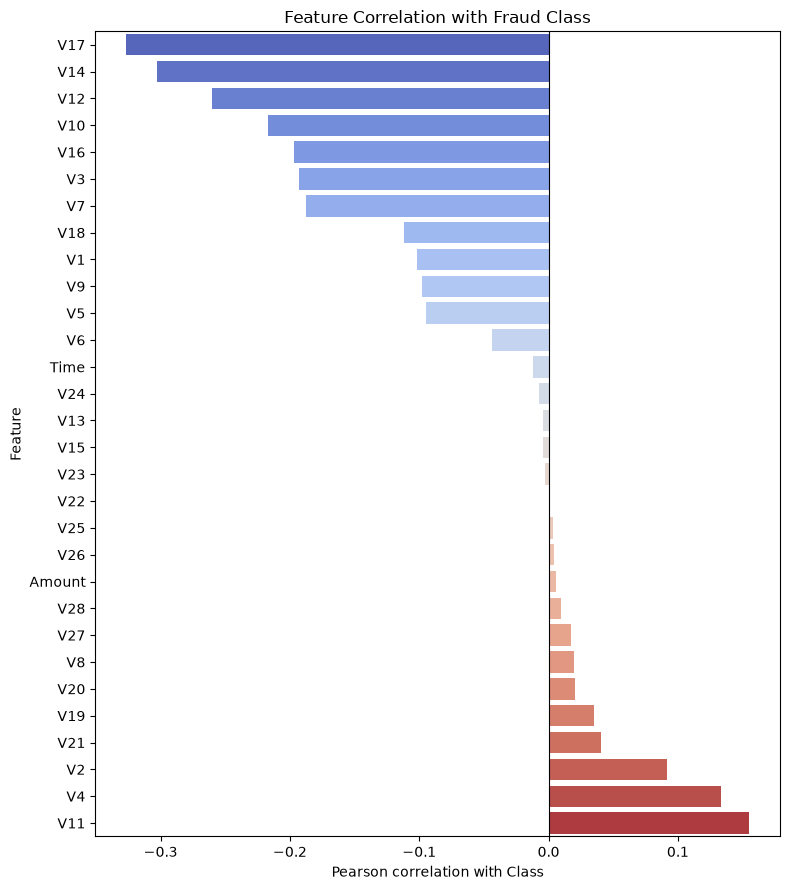

,correlation_with_class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


In [ ]:
# 7. Feature correlation with the fraud label
# The full matrix shows feature relationships; the bar chart makes Class correlations readable.
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 14))
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix of Transaction Features")
plt.show()

class_correlations = correlation_matrix["Class"].drop("Class").sort_values()
plt.figure(figsize=(8, 9))
sns.barplot(
    x=class_correlations.values,
    y=class_correlations.index,
    hue=class_correlations.index,
    palette="coolwarm",
    legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Fraud Class")
plt.xlabel("Pearson correlation with Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(class_correlations.rename("correlation_with_class").to_frame())

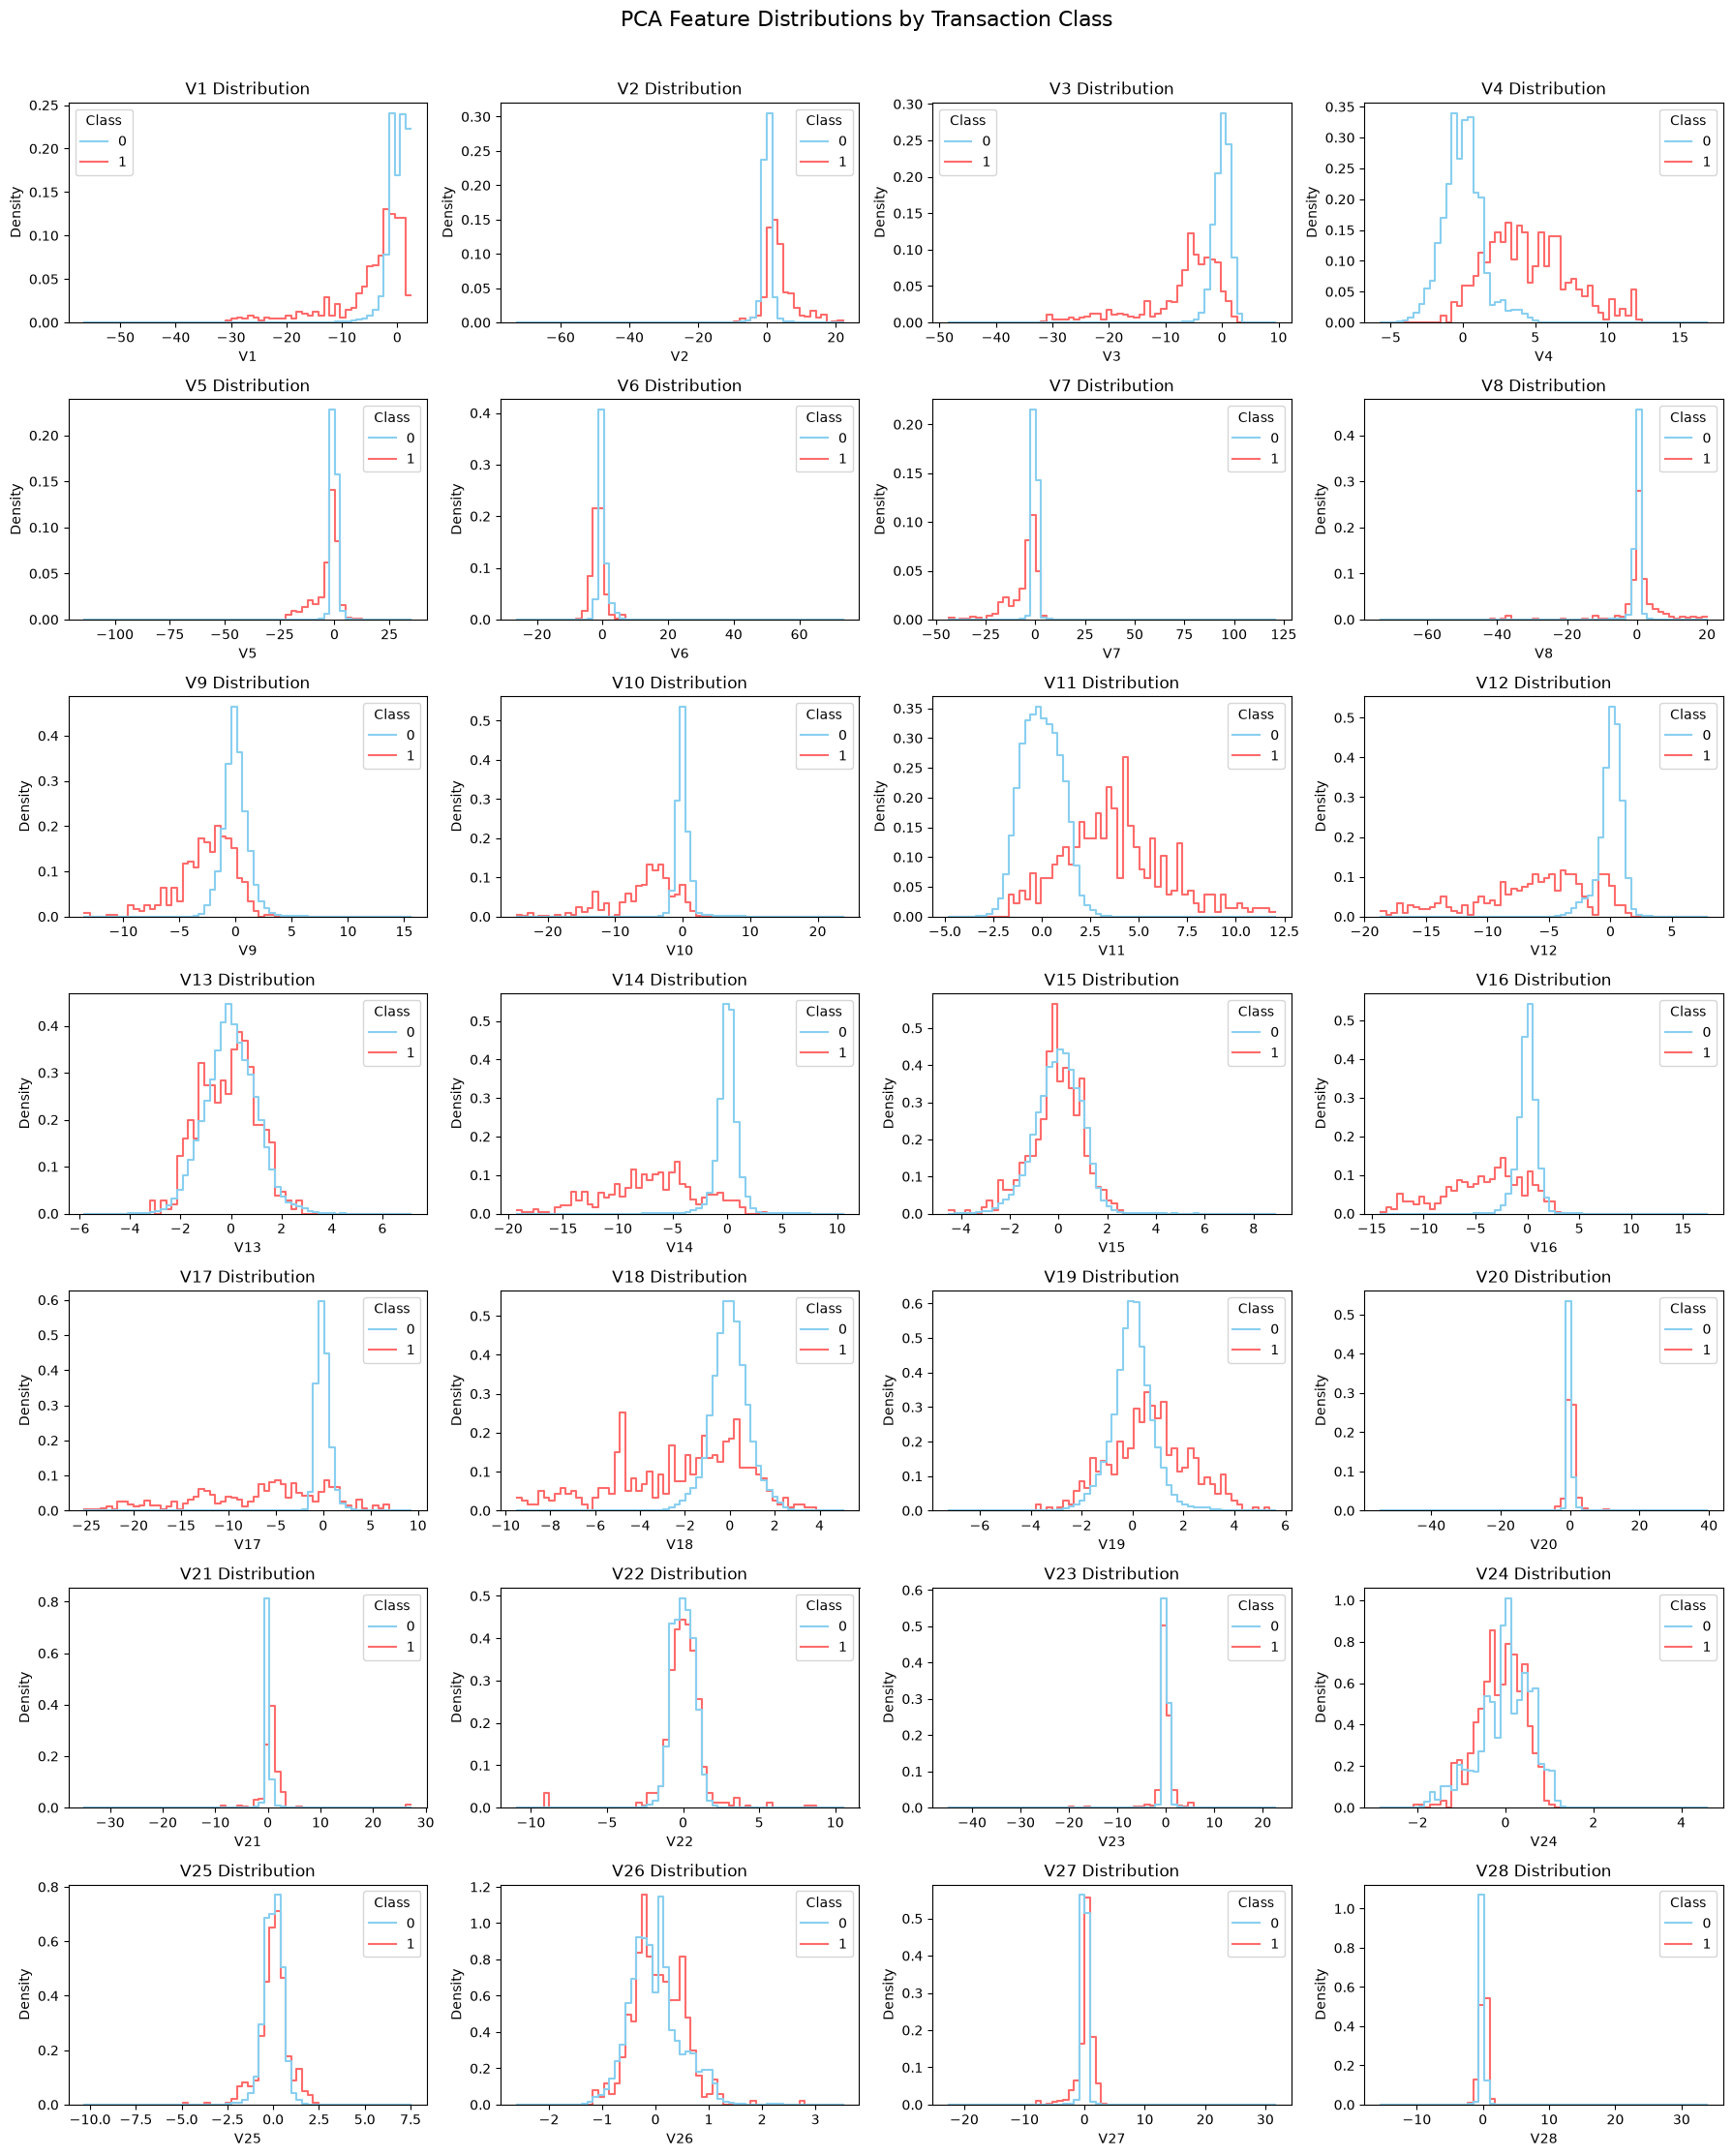

: 

In [ ]:
# 8. Distribution of PCA-transformed features (V1–V28)
pca_features = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 22))
axes = axes.flatten()

for ax, feature in zip(axes, pca_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=60,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        palette=["#89cff0", "#ff6b6b"],
        ax=ax,
    )
    ax.set_title(f"{feature} Distribution")
    ax.set_ylabel("Density")
    ax.legend_.set_title("Class")

plt.suptitle("PCA Feature Distributions by Transaction Class", y=1.01, fontsize=16)
plt.tight_layout()
plt.show()